In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.4,
    'axes.facecolor'   : '#FAFAFA',
    'figure.facecolor' : '#F4F6F9',
})

AZUL  = '#1B4F72'
VERDE = '#1E8449'
LARANJA = '#D35400'
CINZA = '#7F8C8D'

---
# 📋 Análise de Tempo por Ticket e Consultor

Este notebook segue **3 passos**:

1. **Duração do ticket** → diferença entre `data_criacao_ticket` e a última `data_atualizacao` de cada ticket
2. **Tempo total trabalhado por ticket** → soma de todas as entradas de `duracao` (HH:MM:SS) de cada ticket
3. **Tempo médio por consultor** → agrega o tempo total trabalhado por consultor

---

## 📥 Leitura dos dados

In [4]:
df = pd.read_excel('result_28.xlsx')
df = df.drop_duplicates().reset_index(drop=True)

# ── Filtro: apenas tickets FECHADOS ─────────────────────────────────────────
total_antes = len(df)
df = df[df['status_cliente'] == 'FECHADO'].reset_index(drop=True)

print(f'Linhas antes do filtro              : {total_antes:,}')
print(f'Linhas após filtro (FECHADO)        : {len(df):,}')
print(f'Tickets únicos (fechados)           : {df["id_ticket"].nunique():,}')
print(f'Consultores                         : {df["consultor"].nunique():,}')
df.head(3)

Linhas antes do filtro              : 102,791
Linhas após filtro (FECHADO)        : 101,558
Tickets únicos (fechados)           : 25,164
Consultores                         : 10


,tipo_ticket,problema_nosso,servico,meio,status_cliente,categoria,hist,codcli,consultor,classificacao,data_criacao_ticket,id_ticket,titulo,colaborador,data_atualizacao,duracao,mensagem
0,suporte,SIM,Fortinet,Telefone,FECHADO,Problema,Fortigate 40F,1871,Janaina,B,2025-01-02 08:55,345988,DHCP e DNS - Problema,João Paulo,2025-01-02 08:55,NaN,DHCP e DNS - Problema
1,suporte,SIM,Fortinet,Telefone,FECHADO,Problema,Fortigate 40F,1871,Janaina,B,2025-01-02 08:55,345988,DHCP e DNS - Problema,João Paulo,2025-01-02 08:55,00:22:20,"Prezados, bom dia! Tudo bem?Marcelo entrou em ..."
2,suporte,SIM,Fortinet,Telefone,FECHADO,Nova Solicitação,Fortigate 40F,6995,Márcio Takeshi,C,2025-01-02 08:55,345989,Regra de Firewall - Criação - VLANS não navegam,Felipe,2025-01-02 08:55,NaN,Regra de Firewall - Criação - VLANS não navegam


---
## Passo 1 — Duração do Ticket (data de criação → última atualização)

> Cada ticket possui **várias linhas** (uma por interação), cada uma com sua própria `data_atualizacao`.  
> Para calcular quanto tempo o ticket ficou **aberto**, fazemos:
>
> **Duração = última `data_atualizacao` (data + hora) − `data_criacao_ticket` (data + hora)**
>
> Agrupamos por `id_ticket`, pegamos a `data_criacao_ticket` do ticket e o **máximo** de `data_atualizacao` — que representa a última movimentação registrada naquele ticket.

In [5]:
# Converte colunas de data para datetime (com data E hora)
df['data_criacao_dt']    = pd.to_datetime(df['data_criacao_ticket'], format='%Y-%m-%d %H:%M', errors='coerce')
df['data_atualizacao_dt'] = pd.to_datetime(df['data_atualizacao'],   format='%Y-%m-%d %H:%M', errors='coerce')

# ── Passo 1 — lógica correta de datas ────────────────────────────────────────
# A data_criacao_ticket é sempre considerada válida.
# Para a última atualização, ignoramos NaT (datas inválidas dentro das atualizações)
# e pegamos o MÁXIMO das datas válidas de cada ticket.
# Se um ticket não tiver NENHUMA atualização com data válida,
# usamos a própria data_criacao como referência (duração = 0).

def ultima_data_valida(series):
    """Retorna o máximo das datas não-nulas. Se todas forem NaT, retorna NaT."""
    validas = series.dropna()
    return validas.max() if not validas.empty else pd.NaT

resumo_datas = (
    df.groupby('id_ticket')
    .agg(
        data_criacao       = ('data_criacao_dt',    'min'),          # criação: sempre válida
        ultima_atualizacao = ('data_atualizacao_dt', ultima_data_valida)  # última data válida
    )
    .reset_index()
)

# Se não houver nenhuma atualização válida, usa a própria data de criação
# (duração resultante = 0 — indica ticket sem atualizações datadas)
resumo_datas['ultima_atualizacao'] = resumo_datas['ultima_atualizacao'].fillna(
    resumo_datas['data_criacao']
)

# Duração = última atualização válida (data+hora) − data de criação (data+hora)
resumo_datas['duracao_aberto']     = resumo_datas['ultima_atualizacao'] - resumo_datas['data_criacao']
resumo_datas['duracao_aberto_min'] = resumo_datas['duracao_aberto'].dt.total_seconds() / 60
resumo_datas['duracao_aberto_h']   = resumo_datas['duracao_aberto'].dt.total_seconds() / 3600

# Formata legível: Xd Yh Zm
def timedelta_para_str(td):
    if pd.isna(td):
        return 'N/A'
    total_seg = int(td.total_seconds())
    if total_seg < 0:
        return 'inválido'
    dias, resto = divmod(total_seg, 86400)
    horas, resto = divmod(resto, 3600)
    minutos = resto // 60
    partes = []
    if dias:    partes.append(f'{dias}d')
    if horas:   partes.append(f'{horas}h')
    if minutos: partes.append(f'{minutos}min')
    return ' '.join(partes) if partes else '< 1min'

resumo_datas['duracao_formatada'] = resumo_datas['duracao_aberto'].apply(timedelta_para_str)

# Descartados: tickets cuja data_criacao também é inválida (não há base de cálculo)
invalidos = resumo_datas[resumo_datas['data_criacao'].isna()]

# Válidos: todos com data_criacao preenchida
validos_p1 = resumo_datas[resumo_datas['data_criacao'].notna()].copy()

# Classifica os tickets válidos
mesma_hora  = validos_p1[validos_p1['duracao_aberto_min'] == 0]
com_duracao = validos_p1[validos_p1['duracao_aberto_min'] > 0]

print(f'Total de tickets                        : {len(resumo_datas):,}')
print(f'  Com duração > 0                       : {len(com_duracao):,}')
print(f'  Sem atualizações válidas (duração = 0): {len(mesma_hora):,}  (usada data_criacao como referência)')
print(f'  Data de criação inválida (descartados): {len(invalidos):,}')
print()
print('=== Tempo de abertura dos Tickets (todos os válidos) ===')
desc = validos_p1['duracao_aberto_h'].describe()
print(f'  Mediana : {validos_p1["duracao_aberto_h"].median():.1f}h')
print(f'  Média   : {desc["mean"]:.1f}h')
print(f'  Máximo  : {desc["max"]:.1f}h  ({desc["max"]/24:.1f} dias)')
print()
validos_p1[['id_ticket','data_criacao','ultima_atualizacao','duracao_formatada','duracao_aberto_h']].head(10)

Total de tickets                        : 25,164
  Com duração > 0                       : 10,743
  Sem atualizações válidas (duração = 0): 14,322  (usada data_criacao como referência)
  Data de criação inválida (descartados): 99

=== Tempo de abertura dos Tickets (todos os válidos) ===
  Mediana : 0.0h
  Média   : 39.1h
  Máximo  : 7419.0h  (309.1 dias)



,id_ticket,data_criacao,ultima_atualizacao,duracao_formatada,duracao_aberto_h
0,345988,2025-01-02 08:55:00,2025-01-02 08:55:00,< 1min,0.0
1,345989,2025-01-02 08:55:00,2025-01-02 08:55:00,< 1min,0.0
2,345990,2025-01-02 08:55:00,2025-01-08 08:55:00,6d,144.0
3,345991,2025-01-02 09:55:00,2025-01-02 09:55:00,< 1min,0.0
4,345992,2025-01-02 08:55:00,2025-01-02 08:55:00,< 1min,0.0
5,345993,2025-01-02 09:55:00,2025-01-09 08:55:00,6d 23h,167.0
6,345994,2025-01-02 09:55:00,2025-01-03 11:55:00,1d 2h,26.0
7,345995,2025-01-02 09:55:00,2025-01-02 09:55:00,< 1min,0.0
8,345996,2025-01-02 09:55:00,2025-01-02 09:55:00,< 1min,0.0
9,345997,2025-01-02 09:55:00,2025-01-14 11:55:00,12d 2h,290.0


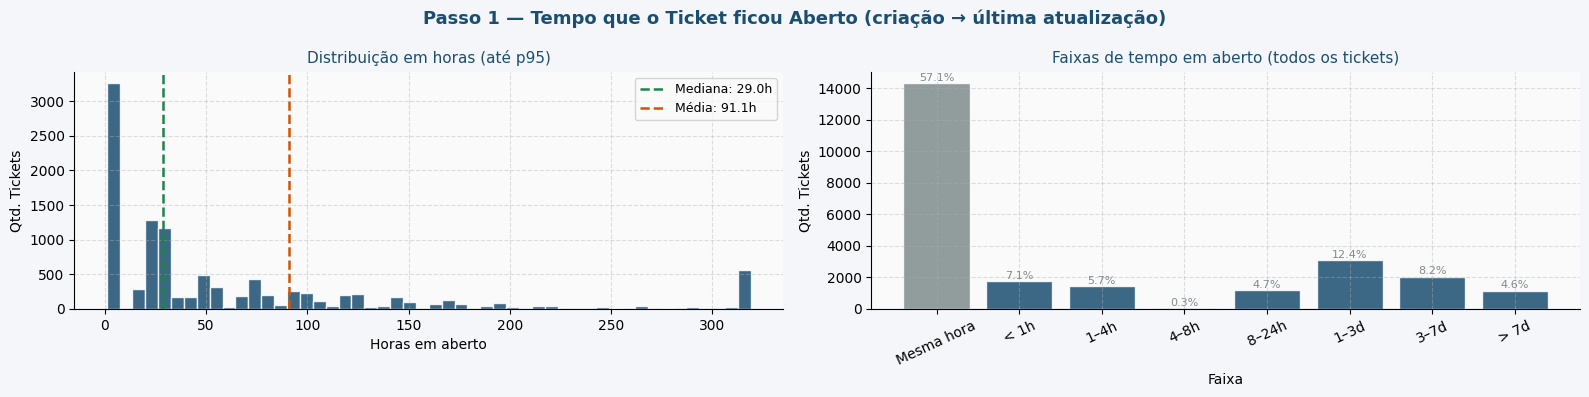

In [6]:
# Visualização — distribuição do tempo de abertura dos tickets
fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor='#F4F6F9')
fig.suptitle('Passo 1 — Tempo que o Ticket ficou Aberto (criação → última atualização)',
             fontsize=13, fontweight='bold', color=AZUL)

# Gráfico 1 — distribuição em horas (tickets com duração > 0, até percentil 95)
ax1 = axes[0]
ax1.set_facecolor('#FAFAFA')
cap_h = com_duracao['duracao_aberto_h'].clip(upper=com_duracao['duracao_aberto_h'].quantile(0.95))
ax1.hist(cap_h, bins=50, color=AZUL, edgecolor='white', alpha=0.85)
mediana_h = com_duracao['duracao_aberto_h'].median()
media_h   = com_duracao['duracao_aberto_h'].mean()
ax1.axvline(mediana_h, color=VERDE,   linestyle='--', linewidth=1.8, label=f'Mediana: {mediana_h:.1f}h')
ax1.axvline(media_h,   color=LARANJA, linestyle='--', linewidth=1.8, label=f'Média: {media_h:.1f}h')
ax1.set_title('Distribuição em horas (até p95)', fontsize=11, color=AZUL)
ax1.set_xlabel('Horas em aberto', fontsize=10)
ax1.set_ylabel('Qtd. Tickets', fontsize=10)
ax1.legend(fontsize=9)

# Gráfico 2 — faixas incluindo 'mesma hora'
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')
bins_dias  = [-1, 0, 1, 4, 8, 24, 72, 168, 9999]
label_dias = ['Mesma hora', '< 1h', '1–4h', '4–8h', '8–24h', '1–3d', '3–7d', '> 7d']
faixas = pd.cut(validos_p1['duracao_aberto_h'], bins=bins_dias, labels=label_dias)
contagem = faixas.value_counts().reindex(label_dias)
pct = contagem / contagem.sum() * 100
cores = [CINZA] + [AZUL] * (len(label_dias) - 1)
bars = ax2.bar(label_dias, contagem, color=cores, edgecolor='white', alpha=0.85)
for bar, p in zip(bars, pct):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{p:.1f}%', ha='center', va='bottom', fontsize=8, color=CINZA)
ax2.set_title('Faixas de tempo em aberto (todos os tickets)', fontsize=11, color=AZUL)
ax2.set_xlabel('Faixa', fontsize=10)
ax2.set_ylabel('Qtd. Tickets', fontsize=10)
ax2.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

---
## Passo 2 — Tempo Total Trabalhado por Ticket (soma das durações HH:MM:SS)

> Cada linha de interação tem um campo `duracao` (HH:MM:SS).  
> O **tempo real trabalhado** em um ticket é a **soma de todas essas durações**.

In [7]:
def parse_duracao(val):
    """Converte HH:MM:SS em segundos. Retorna NaN se inválido."""
    if pd.isna(val) or str(val).strip() == '':
        return np.nan
    try:
        parts = str(val).strip().split(':')
        if len(parts) == 3:
            return int(parts[0])*3600 + int(parts[1])*60 + int(parts[2])
        elif len(parts) == 2:
            return int(parts[0])*3600 + int(parts[1])*60
    except:
        return np.nan

df['duracao_seg'] = df['duracao'].apply(parse_duracao)

print(f'Linhas com duração preenchida : {df["duracao_seg"].notna().sum():,}')
print(f'Linhas sem duração (NaN)      : {df["duracao_seg"].isna().sum():,}')

Linhas com duração preenchida : 55,277
Linhas sem duração (NaN)      : 46,281


In [8]:
# Soma das durações por ticket
tempo_por_ticket = df.groupby('id_ticket').agg(
    total_seg        = ('duracao_seg', 'sum'),
    qtd_interacoes   = ('duracao_seg', 'count')
).reset_index()

tempo_por_ticket['total_min']   = tempo_por_ticket['total_seg'] / 60
tempo_por_ticket['total_horas'] = tempo_por_ticket['total_seg'] / 3600

# Formata como HH:MM:SS para leitura
def seg_para_hhmmss(seg):
    seg = int(seg)
    h, r = divmod(seg, 3600)
    m, s = divmod(r, 60)
    return f'{h:02d}:{m:02d}:{s:02d}'

tempo_por_ticket['total_formatado'] = tempo_por_ticket['total_seg'].apply(seg_para_hhmmss)

print('=== Tempo Total Trabalhado por Ticket (minutos) ===')
print(tempo_por_ticket['total_min'].describe().round(1))
tempo_por_ticket.sort_values('total_min', ascending=False).head(10)

=== Tempo Total Trabalhado por Ticket (minutos) ===
count    25164.0
mean        21.8
std         60.9
min          0.0
25%          3.9
50%          9.1
75%         20.9
max       3296.7
Name: total_min, dtype: float64


,id_ticket,total_seg,qtd_interacoes,total_min,total_horas,total_formatado
5969,353059,197803.0,50,3296.716667,54.945278,54:56:43
17384,366458,173165.0,51,2886.083333,48.101389,48:06:05
209,346233,160749.0,94,2679.150000,44.652500,44:39:09
11266,359259,115151.0,26,1919.183333,31.986389,31:59:11
9192,356847,103221.0,21,1720.350000,28.672500,28:40:21
21427,371159,100010.0,20,1666.833333,27.780556,27:46:50
11083,359016,96902.0,43,1615.033333,26.917222,26:55:02
17021,366046,74345.0,9,1239.083333,20.651389,20:39:05
18643,367919,72766.0,85,1212.766667,20.212778,20:12:46
13028,361379,69039.0,93,1150.650000,19.177500,19:10:39


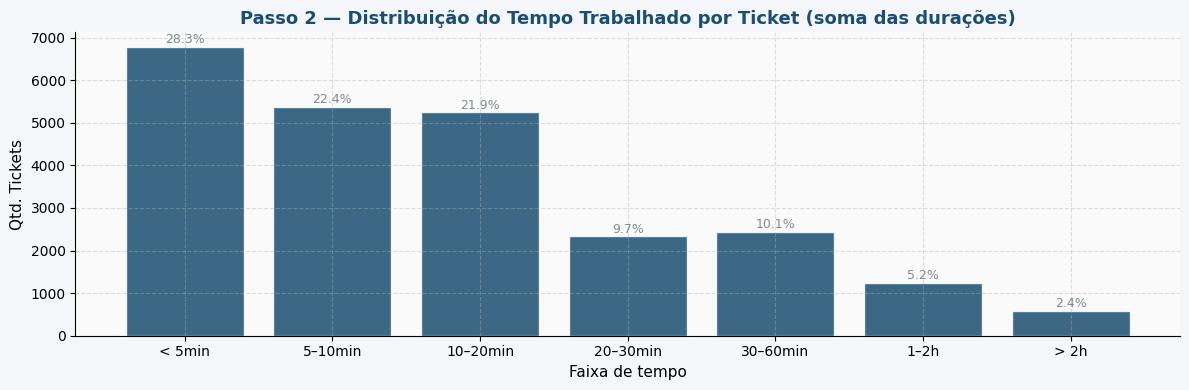

Mediana do tempo trabalhado por ticket : 9.8 min
Média do tempo trabalhado por ticket   : 22.8 min


In [9]:
# Visualização — distribuição do tempo trabalhado por ticket
validos_p2 = tempo_por_ticket[tempo_por_ticket['total_min'] > 0].copy()

bins_faixa  = [0, 5, 10, 20, 30, 60, 120, 99999]
label_faixa = ['< 5min', '5–10min', '10–20min', '20–30min', '30–60min', '1–2h', '> 2h']
validos_p2['faixa'] = pd.cut(validos_p2['total_min'], bins=bins_faixa, labels=label_faixa)

contagem_faixa = validos_p2['faixa'].value_counts().reindex(label_faixa)
pct            = contagem_faixa / contagem_faixa.sum() * 100

fig, ax = plt.subplots(figsize=(12, 4), facecolor='#F4F6F9')
ax.set_facecolor('#FAFAFA')

bars = ax.bar(label_faixa, contagem_faixa, color=AZUL, edgecolor='white', alpha=0.85)
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{p:.1f}%', ha='center', va='bottom', fontsize=9, color=CINZA)

ax.set_title('Passo 2 — Distribuição do Tempo Trabalhado por Ticket (soma das durações)', fontsize=13, fontweight='bold', color=AZUL)
ax.set_xlabel('Faixa de tempo', fontsize=11)
ax.set_ylabel('Qtd. Tickets', fontsize=11)
plt.tight_layout()
plt.show()

mediana_p2 = validos_p2['total_min'].median()
media_p2   = validos_p2['total_min'].mean()
print(f'Mediana do tempo trabalhado por ticket : {mediana_p2:.1f} min')
print(f'Média do tempo trabalhado por ticket   : {media_p2:.1f} min')

---
## Passo 3 — Tempo Médio por Consultor

> Agrega o tempo total trabalhado (soma das durações) por **consultor**,  
> calculando o **total de horas** e a **média por ticket** de cada um.

In [10]:
# Junta o tempo total por ticket com o consultor
# Usa o consultor mais frequente por ticket
consultor_por_ticket = (
    df.groupby('id_ticket')['consultor']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={'consultor': 'consultor_principal'})
)

ticket_consultor = tempo_por_ticket.merge(consultor_por_ticket, on='id_ticket')
ticket_consultor = ticket_consultor[ticket_consultor['total_min'] > 0]

# Agrega por consultor
por_consultor = (
    ticket_consultor
    .groupby('consultor_principal')
    .agg(
        total_horas      = ('total_horas', 'sum'),
        media_min_ticket = ('total_min',   'mean'),
        qtd_tickets      = ('id_ticket',   'count')
    )
    .reset_index()
    .sort_values('total_horas', ascending=False)
)

por_consultor['total_horas']      = por_consultor['total_horas'].round(1)
por_consultor['media_min_ticket'] = por_consultor['media_min_ticket'].round(1)

print('=== Top 15 Consultores por Tempo Total Trabalhado ===')
por_consultor.head(15)

=== Top 15 Consultores por Tempo Total Trabalhado ===


,consultor_principal,total_horas,media_min_ticket,qtd_tickets
5,Janaina,2668.3,21.4,7465
9,Márcio Takeshi,2243.9,21.8,6190
2,Eduardo Nogueira,1631.3,70.6,1386
7,Julio Cesar,1120.7,19.1,3521
6,Jeferson,386.1,14.4,1609
1,CTI-ADM,379.4,12.6,1801
4,Flavio,327.6,30.6,642
8,Karina,313.7,17.1,1102
3,Elaine,51.3,11.1,277
0,Arnizal,0.4,12.9,2


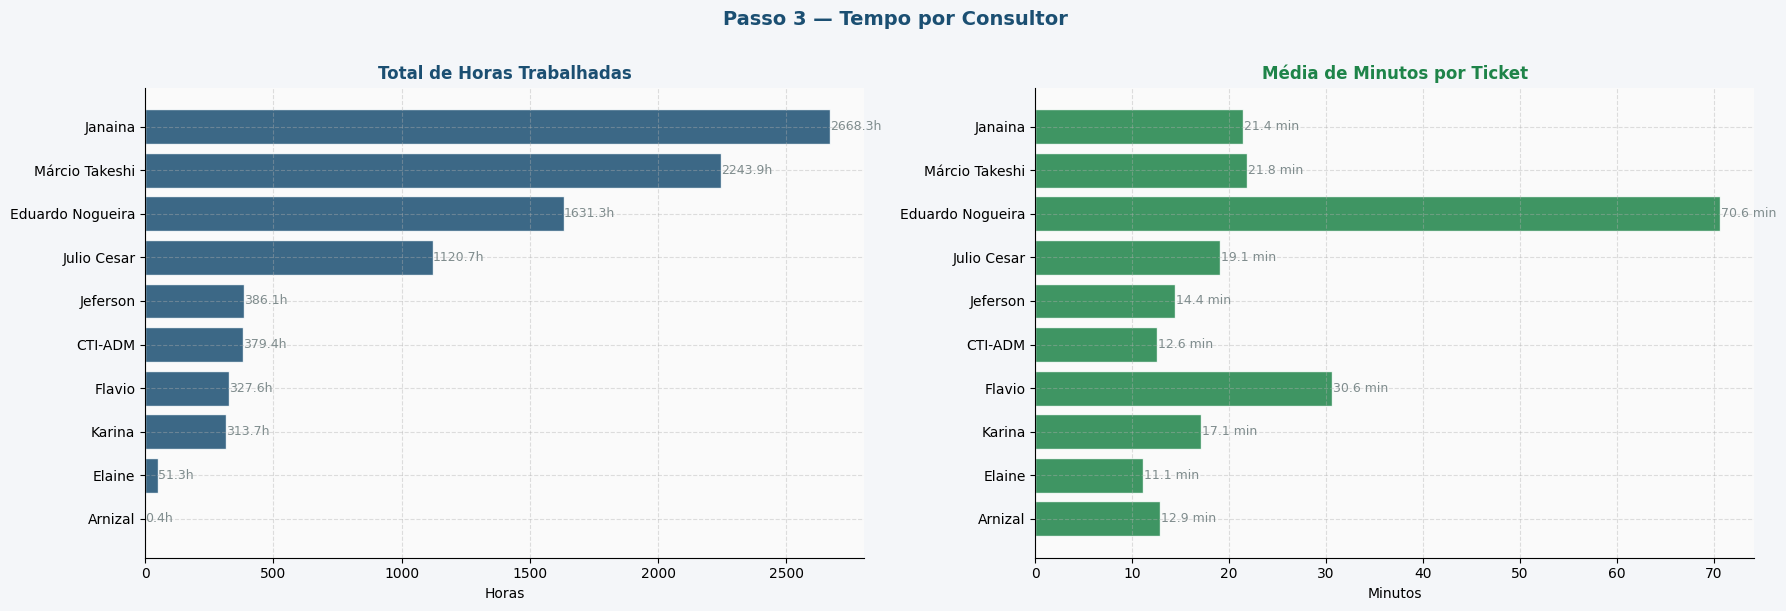

In [11]:
# Visualização — Top 15: total de horas e média por ticket
top15 = por_consultor.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='#F4F6F9')
fig.suptitle('Passo 3 — Tempo por Consultor', fontsize=14, fontweight='bold', color=AZUL, y=1.01)

# Gráfico 1 — Total de horas
ax1 = axes[0]
ax1.set_facecolor('#FAFAFA')
bars1 = ax1.barh(top15['consultor_principal'][::-1], top15['total_horas'][::-1],
                 color=AZUL, edgecolor='white', alpha=0.85)
for bar in bars1:
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}h', va='center', fontsize=9, color=CINZA)
ax1.set_title('Total de Horas Trabalhadas', fontsize=12, fontweight='bold', color=AZUL)
ax1.set_xlabel('Horas', fontsize=10)

# Gráfico 2 — Média por ticket
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')
bars2 = ax2.barh(top15['consultor_principal'][::-1], top15['media_min_ticket'][::-1],
                 color=VERDE, edgecolor='white', alpha=0.85)
for bar in bars2:
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f} min', va='center', fontsize=9, color=CINZA)
ax2.set_title('Média de Minutos por Ticket', fontsize=12, fontweight='bold', color=VERDE)
ax2.set_xlabel('Minutos', fontsize=10)

plt.tight_layout()
plt.show()

---
## 📊 Resumo Final

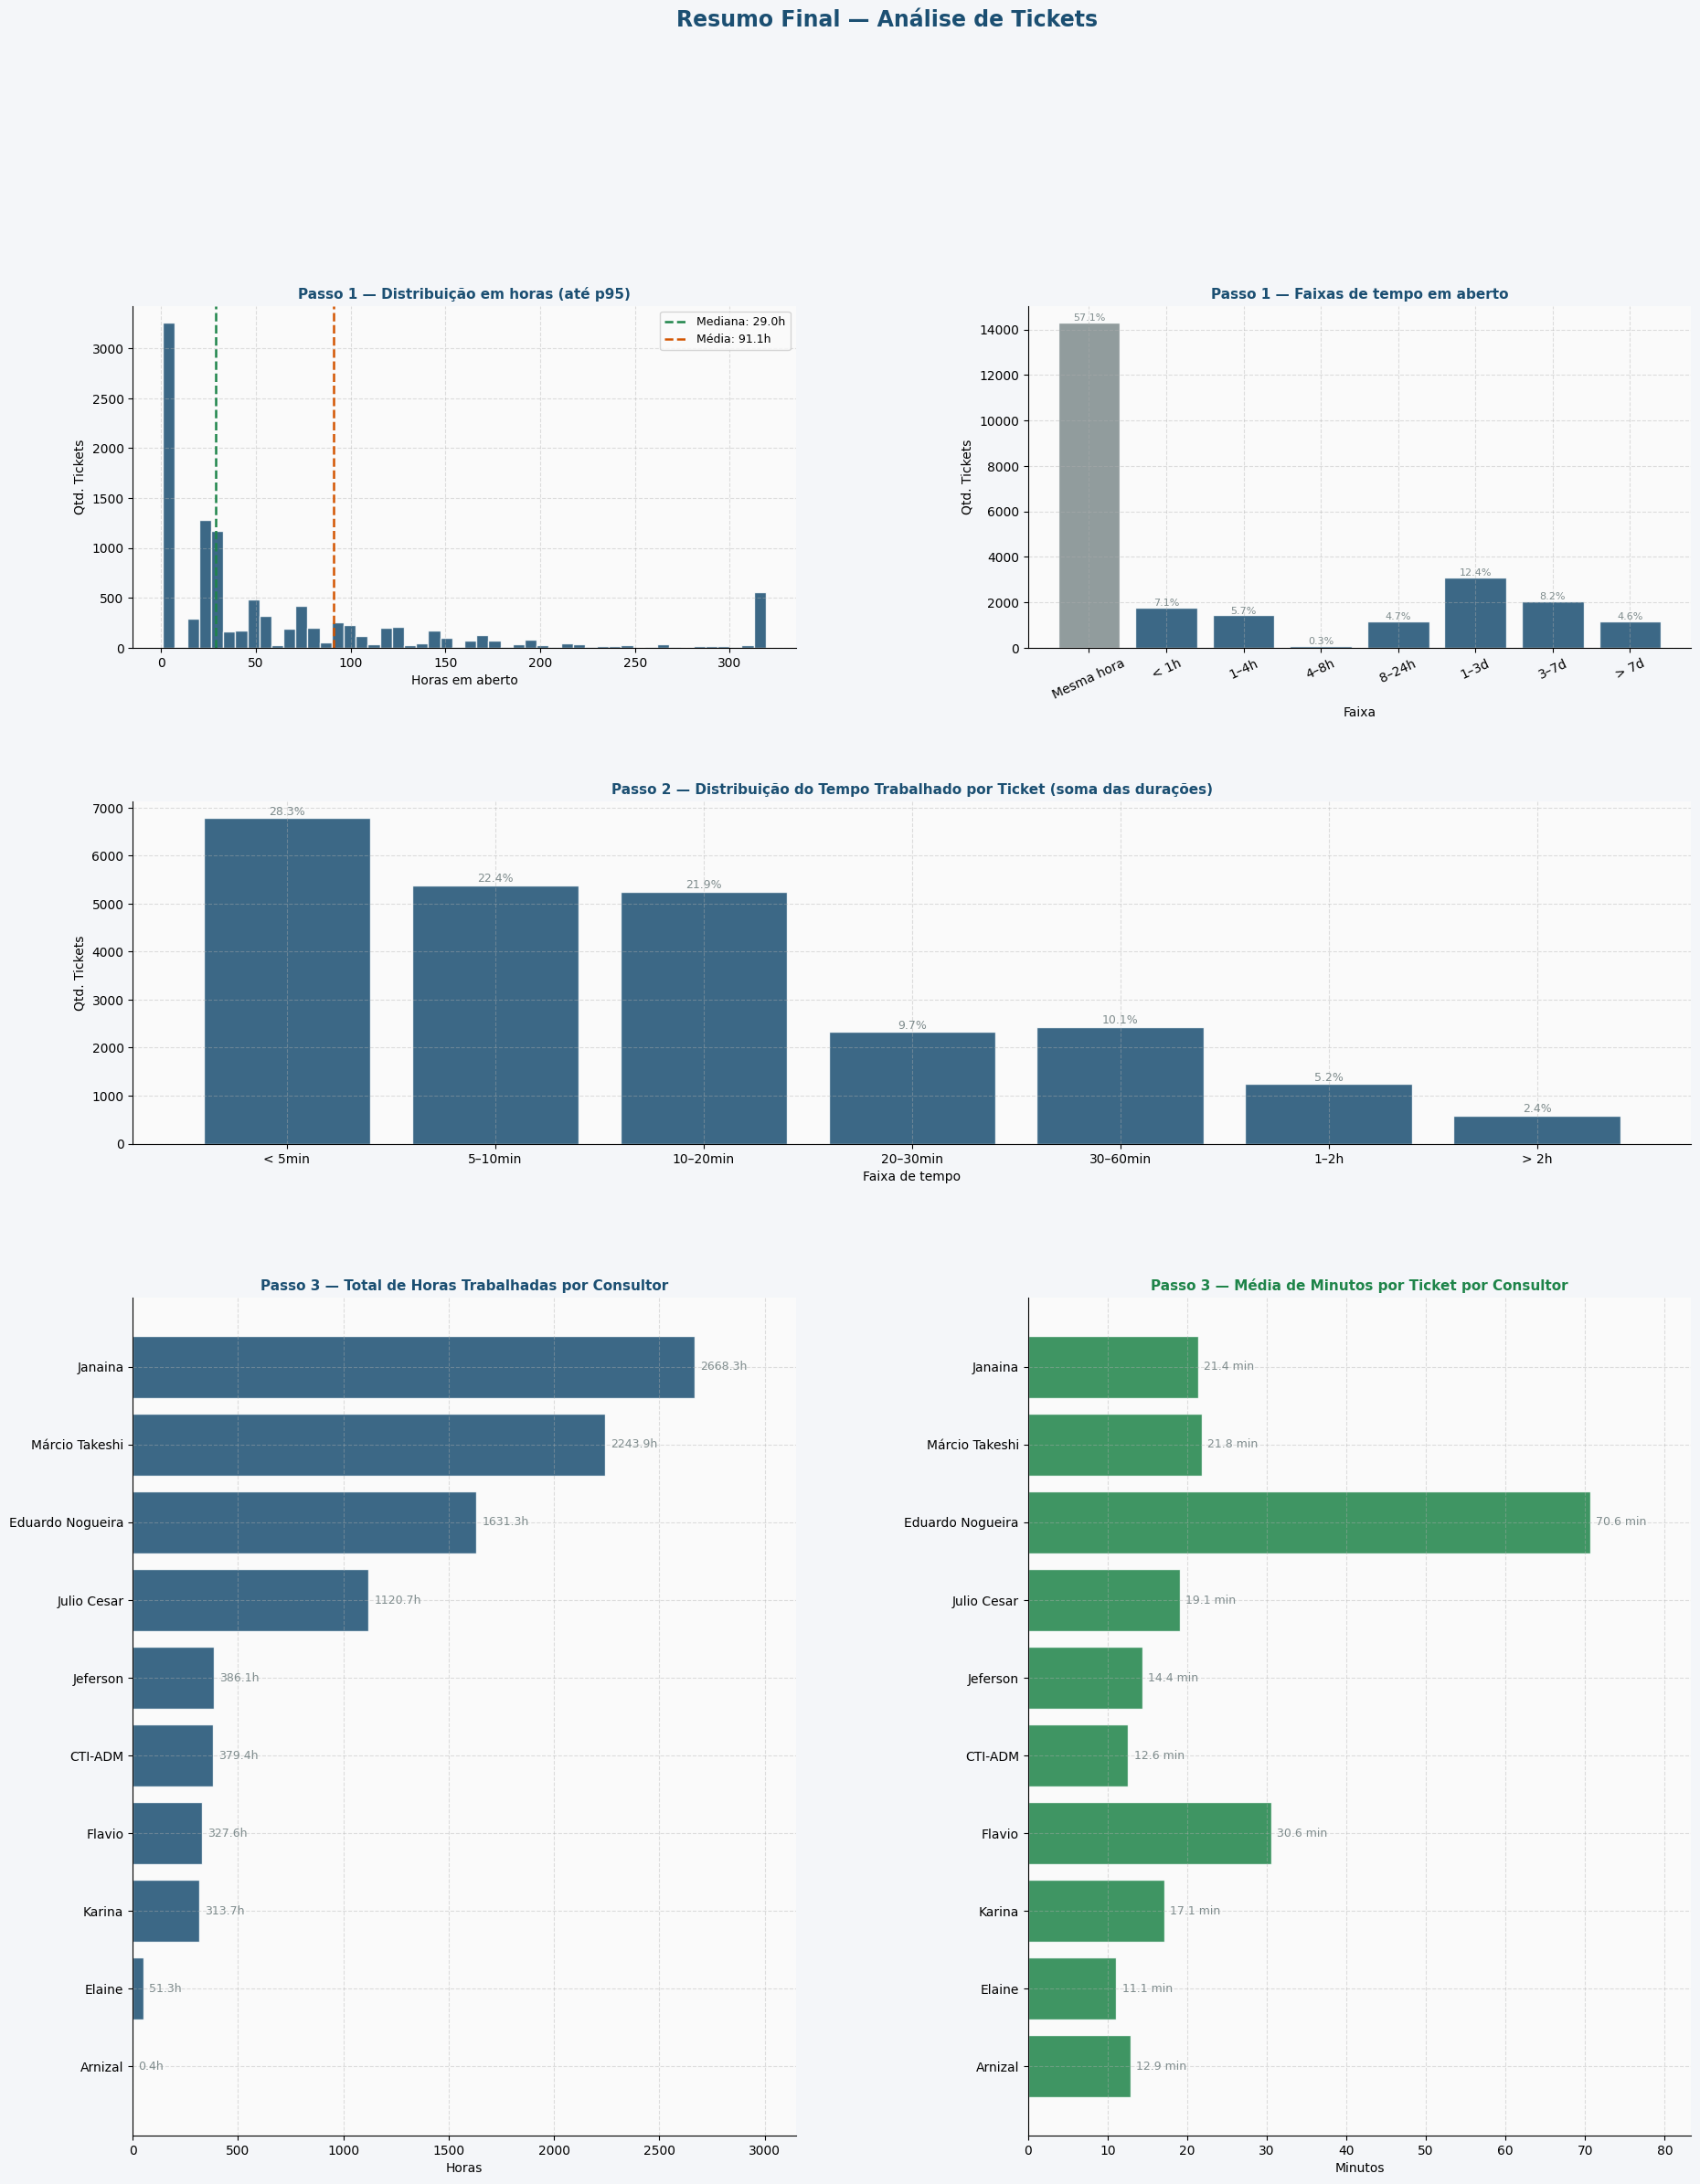

  RESUMO FINAL

📌 PASSO 1 — Duração do ticket (abertura → última atualização)
   Total válidos              : 25,065 tickets
   Sem atualizações datadas   : 14,322 tickets
   Com duração > 0            : 10,743 tickets
   Mediana (> 0)              : 29.0h
   Média   (> 0)              : 91.1h

⏱️  PASSO 2 — Tempo trabalhado por ticket (soma das durações)
   Mediana            : 10 min
   Média              : 23 min
   Tickets analisados : 23,995

👤 PASSO 3 — Top 5 consultores por tempo total
   Janaina              | 2668.3h total |  21.4 min/ticket | 7465 tickets
   Márcio Takeshi       | 2243.9h total |  21.8 min/ticket | 6190 tickets
   Eduardo Nogueira     | 1631.3h total |  70.6 min/ticket | 1386 tickets
   Julio Cesar          | 1120.7h total |  19.1 min/ticket | 3521 tickets
   Jeferson             |  386.1h total |  14.4 min/ticket | 1609 tickets



In [12]:
# ═══════════════════════════════════════════════════════════════
# RESUMO FINAL — painel visual com todos os gráficos principais
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 26), facecolor='#F4F6F9')
fig.suptitle('Resumo Final — Análise de Tickets', fontsize=17,
             fontweight='bold', color=AZUL, y=1.005)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Linha 1: Passo 1 — Distribuição em horas e faixas ───────────────────────
ax1a = fig.add_subplot(gs[0, 0])
ax1b = fig.add_subplot(gs[0, 1])

ax1a.set_facecolor('#FAFAFA')
cap_h = com_duracao['duracao_aberto_h'].clip(upper=com_duracao['duracao_aberto_h'].quantile(0.95))
ax1a.hist(cap_h, bins=50, color=AZUL, edgecolor='white', alpha=0.85)
mediana_h = com_duracao['duracao_aberto_h'].median()
media_h   = com_duracao['duracao_aberto_h'].mean()
ax1a.axvline(mediana_h, color=VERDE,   linestyle='--', linewidth=1.8, label=f'Mediana: {mediana_h:.1f}h')
ax1a.axvline(media_h,   color=LARANJA, linestyle='--', linewidth=1.8, label=f'Média: {media_h:.1f}h')
ax1a.set_title('Passo 1 — Distribuição em horas (até p95)', fontsize=11, color=AZUL, fontweight='bold')
ax1a.set_xlabel('Horas em aberto', fontsize=10)
ax1a.set_ylabel('Qtd. Tickets', fontsize=10)
ax1a.legend(fontsize=9)

ax1b.set_facecolor('#FAFAFA')
bins_dias  = [-1, 0, 1, 4, 8, 24, 72, 168, 9999]
label_dias = ['Mesma hora', '< 1h', '1–4h', '4–8h', '8–24h', '1–3d', '3–7d', '> 7d']
faixas   = pd.cut(validos_p1['duracao_aberto_h'], bins=bins_dias, labels=label_dias)
contagem = faixas.value_counts().reindex(label_dias)
pct      = contagem / contagem.sum() * 100
cores    = [CINZA] + [AZUL] * (len(label_dias) - 1)
bars     = ax1b.bar(label_dias, contagem, color=cores, edgecolor='white', alpha=0.85)
for bar, p in zip(bars, pct):
    ax1b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
              f'{p:.1f}%', ha='center', va='bottom', fontsize=8, color=CINZA)
ax1b.set_title('Passo 1 — Faixas de tempo em aberto', fontsize=11, color=AZUL, fontweight='bold')
ax1b.set_xlabel('Faixa', fontsize=10)
ax1b.set_ylabel('Qtd. Tickets', fontsize=10)
ax1b.tick_params(axis='x', rotation=25)

# ── Linha 2: Passo 2 — Distribuição do tempo trabalhado ─────────────────────
ax2 = fig.add_subplot(gs[1, :])   # ocupa as 2 colunas
ax2.set_facecolor('#FAFAFA')

bins_faixa  = [0, 5, 10, 20, 30, 60, 120, 99999]
label_faixa = ['< 5min', '5–10min', '10–20min', '20–30min', '30–60min', '1–2h', '> 2h']
validos_p2_plot = tempo_por_ticket[tempo_por_ticket['total_min'] > 0].copy()
validos_p2_plot['faixa'] = pd.cut(validos_p2_plot['total_min'], bins=bins_faixa, labels=label_faixa)
contagem_faixa = validos_p2_plot['faixa'].value_counts().reindex(label_faixa)
pct_faixa      = contagem_faixa / contagem_faixa.sum() * 100

bars2 = ax2.bar(label_faixa, contagem_faixa, color=AZUL, edgecolor='white', alpha=0.85)
for bar, p in zip(bars2, pct_faixa):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{p:.1f}%', ha='center', va='bottom', fontsize=9, color=CINZA)
ax2.set_title('Passo 2 — Distribuição do Tempo Trabalhado por Ticket (soma das durações)',
              fontsize=11, color=AZUL, fontweight='bold')
ax2.set_xlabel('Faixa de tempo', fontsize=10)
ax2.set_ylabel('Qtd. Tickets', fontsize=10)

# ── Linha 3 e 4: Passo 3 — Consultores ──────────────────────────────────────
top15 = por_consultor.head(15).copy()

ax3a = fig.add_subplot(gs[2:, 0])
ax3a.set_facecolor('#FAFAFA')
bars3a = ax3a.barh(top15['consultor_principal'][::-1], top15['total_horas'][::-1],
                   color=AZUL, edgecolor='white', alpha=0.85)
for bar in bars3a:
    ax3a.text(bar.get_width() + top15['total_horas'].max() * 0.01,
              bar.get_y() + bar.get_height()/2,
              f'{bar.get_width():.1f}h', va='center', fontsize=9, color=CINZA)
ax3a.set_title('Passo 3 — Total de Horas Trabalhadas por Consultor',
               fontsize=11, color=AZUL, fontweight='bold')
ax3a.set_xlabel('Horas', fontsize=10)
ax3a.set_xlim(right=top15['total_horas'].max() * 1.18)

ax3b = fig.add_subplot(gs[2:, 1])
ax3b.set_facecolor('#FAFAFA')
bars3b = ax3b.barh(top15['consultor_principal'][::-1], top15['media_min_ticket'][::-1],
                   color=VERDE, edgecolor='white', alpha=0.85)
for bar in bars3b:
    ax3b.text(bar.get_width() + top15['media_min_ticket'].max() * 0.01,
              bar.get_y() + bar.get_height()/2,
              f'{bar.get_width():.1f} min', va='center', fontsize=9, color=CINZA)
ax3b.set_title('Passo 3 — Média de Minutos por Ticket por Consultor',
               fontsize=11, color=VERDE, fontweight='bold')
ax3b.set_xlabel('Minutos', fontsize=10)
ax3b.set_xlim(right=top15['media_min_ticket'].max() * 1.18)

plt.tight_layout()
plt.show()

# ── Resumo textual ───────────────────────────────────────────────────────────
print('=' * 60)
print('  RESUMO FINAL')
print('=' * 60)
print(f'\n📌 PASSO 1 — Duração do ticket (abertura → última atualização)')
print(f'   Total válidos              : {len(validos_p1):,} tickets')
print(f'   Sem atualizações datadas   : {len(mesma_hora):,} tickets')
print(f'   Com duração > 0            : {len(com_duracao):,} tickets')
print(f'   Mediana (> 0)              : {com_duracao["duracao_aberto_h"].median():.1f}h')
print(f'   Média   (> 0)              : {com_duracao["duracao_aberto_h"].mean():.1f}h')
print(f'\n⏱️  PASSO 2 — Tempo trabalhado por ticket (soma das durações)')
print(f'   Mediana            : {validos_p2_plot["total_min"].median():.0f} min')
print(f'   Média              : {validos_p2_plot["total_min"].mean():.0f} min')
print(f'   Tickets analisados : {len(validos_p2_plot):,}')
print(f'\n👤 PASSO 3 — Top 5 consultores por tempo total')
for _, row in por_consultor.head(5).iterrows():
    print(f'   {row["consultor_principal"]:<20} | {row["total_horas"]:>6.1f}h total | {row["media_min_ticket"]:>5.1f} min/ticket | {row["qtd_tickets"]:>4} tickets')
print('\n' + '=' * 60)


---
## Passo 4 — Tempo Trabalhado e Duração em Aberto por Título

> **Distinção importante:**
> - Linhas **com `duracao`** = consultor trabalhou ativamente naquele ticket
> - Linhas **sem `duracao`** (NaN) = resposta do cliente ou movimentação sem trabalho de consultor
>
> Por isso:
> - **Tempo trabalhado** = soma apenas das linhas com `duracao` preenchida
> - **Duração em aberto** = tempo total entre criação e última atualização válida (Passo 1)
>
> Os títulos são normalizados em duas etapas:
> 1. **Limpeza textual** — minúsculas, sem acentos, remoção de datas e IDs numéricos
> 2. **Merge semântico** — variações do mesmo assunto são unificadas

In [13]:
import unicodedata, re

# ── 1. Normalização textual dos títulos ──────────────────────────────────────
def normalizar_titulo(t):
    if pd.isna(t):
        return 'sem titulo'
    t = str(t).strip().lower()
    t = unicodedata.normalize('NFD', t)
    t = ''.join(c for c in t if unicodedata.category(c) != 'Mn')  # remove acentos
    t = re.sub(r'[^a-z0-9\s\-]', ' ', t)                          # só letras/números/hífen
    t = re.sub(r'\s+', ' ', t).strip()
    t = re.sub(r'\b\d{1,2}/\d{1,2}(/\d{2,4})?\b', '', t)         # remove datas dd/mm/yyyy
    t = re.sub(r'^\d+\s*[-\s]*', '', t)                            # remove ID numérico no início
    t = re.sub(r'\s*[-\s]*\d+$', '', t)                            # remove ID numérico no fim
    t = re.sub(r'\s+', ' ', t).strip()
    return t if t else 'sem titulo'

df['titulo_key'] = df['titulo'].apply(normalizar_titulo)

# ── 2. Merge semântico — unifica variações do mesmo assunto ─────────────────
merge_map = {
    'liberar site'             : 'liberacao de site',
    'liberacao de url'         : 'liberacao de site',
    'liberar url'              : 'liberacao de site',
    'proativo - monitoramento' : 'pro-ativo monitoramento',
    'pro ativo monitoramento'  : 'pro-ativo monitoramento',
    'lentidao'                 : 'lentidao no link',
    'link lento'               : 'lentidao no link',
    'rompimento de link'       : 'rompimento',
    'rompimento de cabo'       : 'rompimento',
}
df['titulo_key'] = df['titulo_key'].replace(merge_map)

print(f'Títulos únicos (bruto)        : {df["titulo"].nunique():,}')
print(f'Títulos únicos (normalizados) : {df["titulo_key"].nunique():,}')


Títulos únicos (bruto)        : 15,253
Títulos únicos (normalizados) : 14,286


In [14]:
# ── 3. Tempo trabalhado por título ───────────────────────────────────────────
# Apenas linhas COM duracao preenchida representam trabalho ativo do consultor.
# Linhas sem duracao (NaN) = resposta do cliente ou movimentação — ignoradas aqui.

tempo_titulo = (
    df[df['duracao_seg'].notna()]          # filtra só linhas com trabalho de consultor
    .groupby('titulo_key')
    .agg(
        total_seg    = ('duracao_seg', 'sum'),
        qtd_tickets  = ('id_ticket',   'nunique'),
    )
    .reset_index()
)
tempo_titulo['total_horas']      = tempo_titulo['total_seg'] / 3600
tempo_titulo['media_min_ticket'] = (tempo_titulo['total_seg'] / 60) / tempo_titulo['qtd_tickets']

# ── 4. Duração em aberto por título (criação → última atualização válida) ────
# titulo_key dominante por ticket (consultor que mais atuou)
titulo_por_ticket = (
    df.groupby('id_ticket')['titulo_key']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else 'sem titulo')
    .reset_index()
)

duracao_titulo = (
    validos_p1
    .merge(titulo_por_ticket, on='id_ticket', how='left')
    .groupby('titulo_key')
    .agg(
        media_duracao_h   = ('duracao_aberto_h', 'mean'),
        mediana_duracao_h = ('duracao_aberto_h', 'median'),
    )
    .reset_index()
)

# ── 5. Junta as métricas ─────────────────────────────────────────────────────
por_titulo = tempo_titulo.merge(duracao_titulo, on='titulo_key', how='left')

# Título de exibição: capitaliza a chave normalizada
def titulo_display(k):
    return k.replace('-', ' ').title().replace('  ', ' ').strip()

por_titulo['titulo_display'] = por_titulo['titulo_key'].apply(titulo_display)
por_titulo = por_titulo.sort_values('total_horas', ascending=False)

print(f'Títulos com tempo trabalhado registrado: {len(por_titulo):,}')
print('\nTop 20 por Tempo Trabalhado pelos Consultores:')
por_titulo[['titulo_display','qtd_tickets','total_horas','media_min_ticket','media_duracao_h']].head(20)


Títulos com tempo trabalhado registrado: 14,286

Top 20 por Tempo Trabalhado pelos Consultores:


,titulo_display,qtd_tickets,total_horas,media_min_ticket,media_duracao_h
7493,Link Indisponivel,1569,388.831389,14.869269,28.707207
5862,Instabilidade,450,168.918889,22.522519,20.526786
7961,Migracao De Servidor Ksc,84,115.443889,82.459921,618.535714
13611,Webfilter Liberacao,321,79.598889,14.878297,5.903125
12959,Vpn Client Problema,135,61.904722,27.513210,11.835821
746,Ajustes Nas Controladora Kaspersky Ksc,1,54.945278,3296.716667,2110.000000
13284,Vpn Site To Site Problema,117,53.365278,27.366809,8.525862
6927,Liberacao De Site,359,51.735278,8.646565,16.339031
8876,Preparativos Techday Cti Equipamentos Aprese...,1,48.101389,2886.083333,868.000000
6271,Interfaces Problema,106,46.125278,26.108648,4.114286


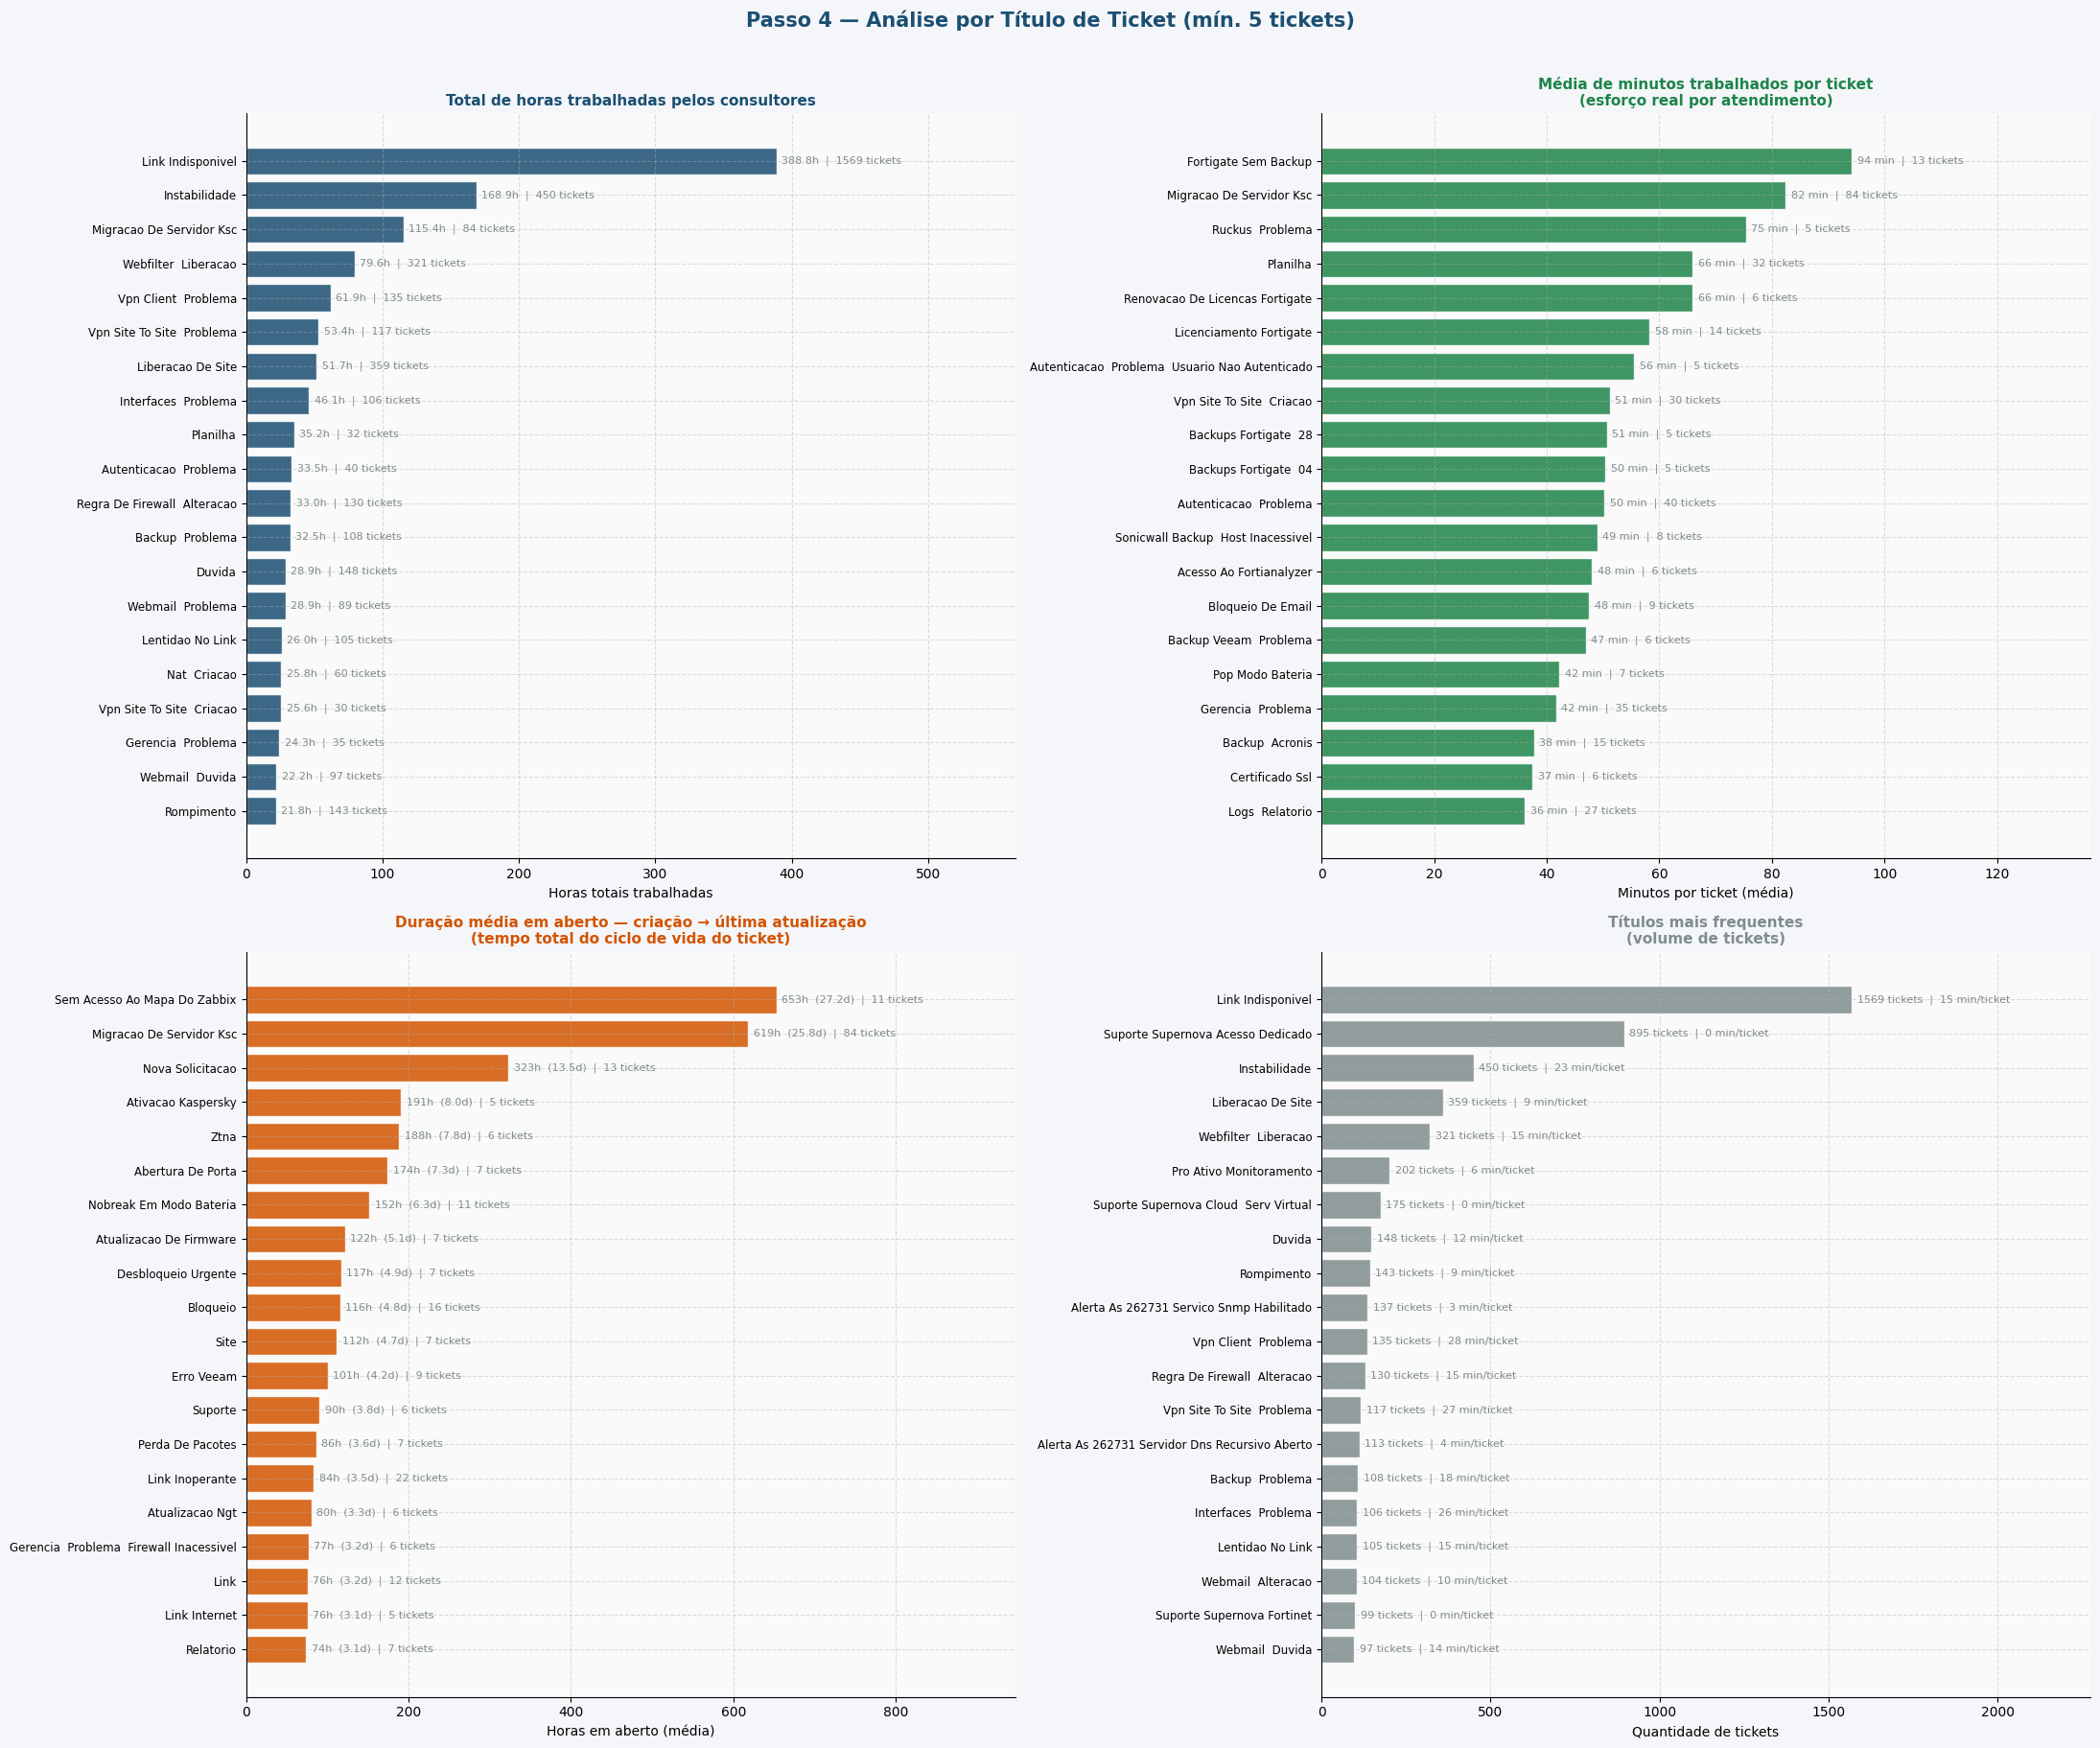


=== Top 10 por esforço médio por atendimento (mín. 5 tickets) ===
  Fortigate Sem Backup                               |     94 min/ticket | 13 tickets | 20.4h total
  Migracao De Servidor Ksc                           |     82 min/ticket | 84 tickets | 115.4h total
  Ruckus  Problema                                   |     75 min/ticket | 5 tickets | 6.3h total
  Planilha                                           |     66 min/ticket | 32 tickets | 35.2h total
  Renovacao De Licencas Fortigate                    |     66 min/ticket | 6 tickets | 6.6h total
  Licenciamento Fortigate                            |     58 min/ticket | 14 tickets | 13.6h total
  Autenticacao  Problema  Usuario Nao Autenticado    |     56 min/ticket | 5 tickets | 4.6h total
  Vpn Site To Site  Criacao                          |     51 min/ticket | 30 tickets | 25.6h total
  Backups Fortigate  28                              |     51 min/ticket | 5 tickets | 4.2h total
  Backups Fortigate  04                 

In [15]:
# ── Visualização — 4 gráficos por título ─────────────────────────────────────
# Para evitar distorção entre volume e esforço, separamos em 4 visões:
#   1. Total de horas trabalhadas (volume × esforço) — títulos mais custosos globalmente
#   2. Média de minutos por ticket                   — esforço real por atendimento
#   3. Duração média em aberto                       — títulos que mais demoram fechar
#   4. Quantidade de tickets                         — títulos mais frequentes

# Filtra títulos com ao menos 5 tickets para evitar distorção de casos únicos
por_titulo_filtrado = por_titulo[por_titulo['qtd_tickets'] >= 5].copy()

top20_total   = por_titulo_filtrado.nlargest(20, 'total_horas').sort_values('total_horas')
top20_media   = por_titulo_filtrado.nlargest(20, 'media_min_ticket').sort_values('media_min_ticket')
top20_duracao = (por_titulo_filtrado[por_titulo_filtrado['media_duracao_h'].notna()]
                 .nlargest(20, 'media_duracao_h').sort_values('media_duracao_h'))
top20_freq    = por_titulo_filtrado.nlargest(20, 'qtd_tickets').sort_values('qtd_tickets')

fig, axes = plt.subplots(2, 2, figsize=(22, 18), facecolor='#F4F6F9')
fig.suptitle('Passo 4 — Análise por Título de Ticket (mín. 5 tickets)',
             fontsize=15, fontweight='bold', color=AZUL, y=1.01)

def barh_label(ax, bars, labels, color=CINZA, size=8):
    xmax = max(b.get_width() for b in bars)
    for bar, lbl in zip(bars, labels):
        ax.text(bar.get_width() + xmax * 0.01,
                bar.get_y() + bar.get_height() / 2,
                lbl, va='center', fontsize=size, color=color)
    ax.set_xlim(right=xmax * 1.45)

# ── Gráfico 1 — Total de horas trabalhadas ───────────────────────────────────
ax = axes[0][0]; ax.set_facecolor('#FAFAFA')
bars = ax.barh(top20_total['titulo_display'], top20_total['total_horas'],
               color=AZUL, edgecolor='white', alpha=0.85)
barh_label(ax, bars,
           [f'{b.get_width():.1f}h  |  {int(q)} tickets'
            for b, q in zip(bars, top20_total['qtd_tickets'])])
ax.set_title('Total de horas trabalhadas pelos consultores', fontsize=11, fontweight='bold', color=AZUL)
ax.set_xlabel('Horas totais trabalhadas', fontsize=10)
ax.tick_params(axis='y', labelsize=8.5)

# ── Gráfico 2 — Média de minutos por ticket ──────────────────────────────────
ax = axes[0][1]; ax.set_facecolor('#FAFAFA')
bars = ax.barh(top20_media['titulo_display'], top20_media['media_min_ticket'],
               color=VERDE, edgecolor='white', alpha=0.85)
barh_label(ax, bars,
           [f'{b.get_width():.0f} min  |  {int(q)} tickets'
            for b, q in zip(bars, top20_media['qtd_tickets'])])
ax.set_title('Média de minutos trabalhados por ticket\n(esforço real por atendimento)', fontsize=11, fontweight='bold', color=VERDE)
ax.set_xlabel('Minutos por ticket (média)', fontsize=10)
ax.tick_params(axis='y', labelsize=8.5)

# ── Gráfico 3 — Duração média em aberto ──────────────────────────────────────
ax = axes[1][0]; ax.set_facecolor('#FAFAFA')
bars = ax.barh(top20_duracao['titulo_display'], top20_duracao['media_duracao_h'],
               color=LARANJA, edgecolor='white', alpha=0.85)
barh_label(ax, bars,
           [f'{b.get_width():.0f}h  ({b.get_width()/24:.1f}d)  |  {int(q)} tickets'
            for b, q in zip(bars, top20_duracao['qtd_tickets'])])
ax.set_title('Duração média em aberto — criação → última atualização\n(tempo total do ciclo de vida do ticket)', fontsize=11, fontweight='bold', color=LARANJA)
ax.set_xlabel('Horas em aberto (média)', fontsize=10)
ax.tick_params(axis='y', labelsize=8.5)

# ── Gráfico 4 — Quantidade de tickets ────────────────────────────────────────
ax = axes[1][1]; ax.set_facecolor('#FAFAFA')
bars = ax.barh(top20_freq['titulo_display'], top20_freq['qtd_tickets'],
               color=CINZA, edgecolor='white', alpha=0.85)
barh_label(ax, bars,
           [f'{int(b.get_width())} tickets  |  {q:.0f} min/ticket'
            for b, q in zip(bars, top20_freq['media_min_ticket'])])
ax.set_title('Títulos mais frequentes\n(volume de tickets)', fontsize=11, fontweight='bold', color=CINZA)
ax.set_xlabel('Quantidade de tickets', fontsize=10)
ax.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.show()

print('\n=== Top 10 por esforço médio por atendimento (mín. 5 tickets) ===')
for _, r in top20_media.sort_values('media_min_ticket', ascending=False).head(10).iterrows():
    print(f'  {r["titulo_display"]:<50} | {r["media_min_ticket"]:>6.0f} min/ticket | {int(r["qtd_tickets"])} tickets | {r["total_horas"]:.1f}h total')


---
## Passo 5 — Problemas Recorrentes e Sazonalidade por Serviço

> Analisa os **títulos mais frequentes** por serviço e a **evolução mensal de tickets**
> separada por serviço, revelando sazonalidade e concentração de demanda.


Serviços analisados: 11
Período             : Jan/25 → Dec/25


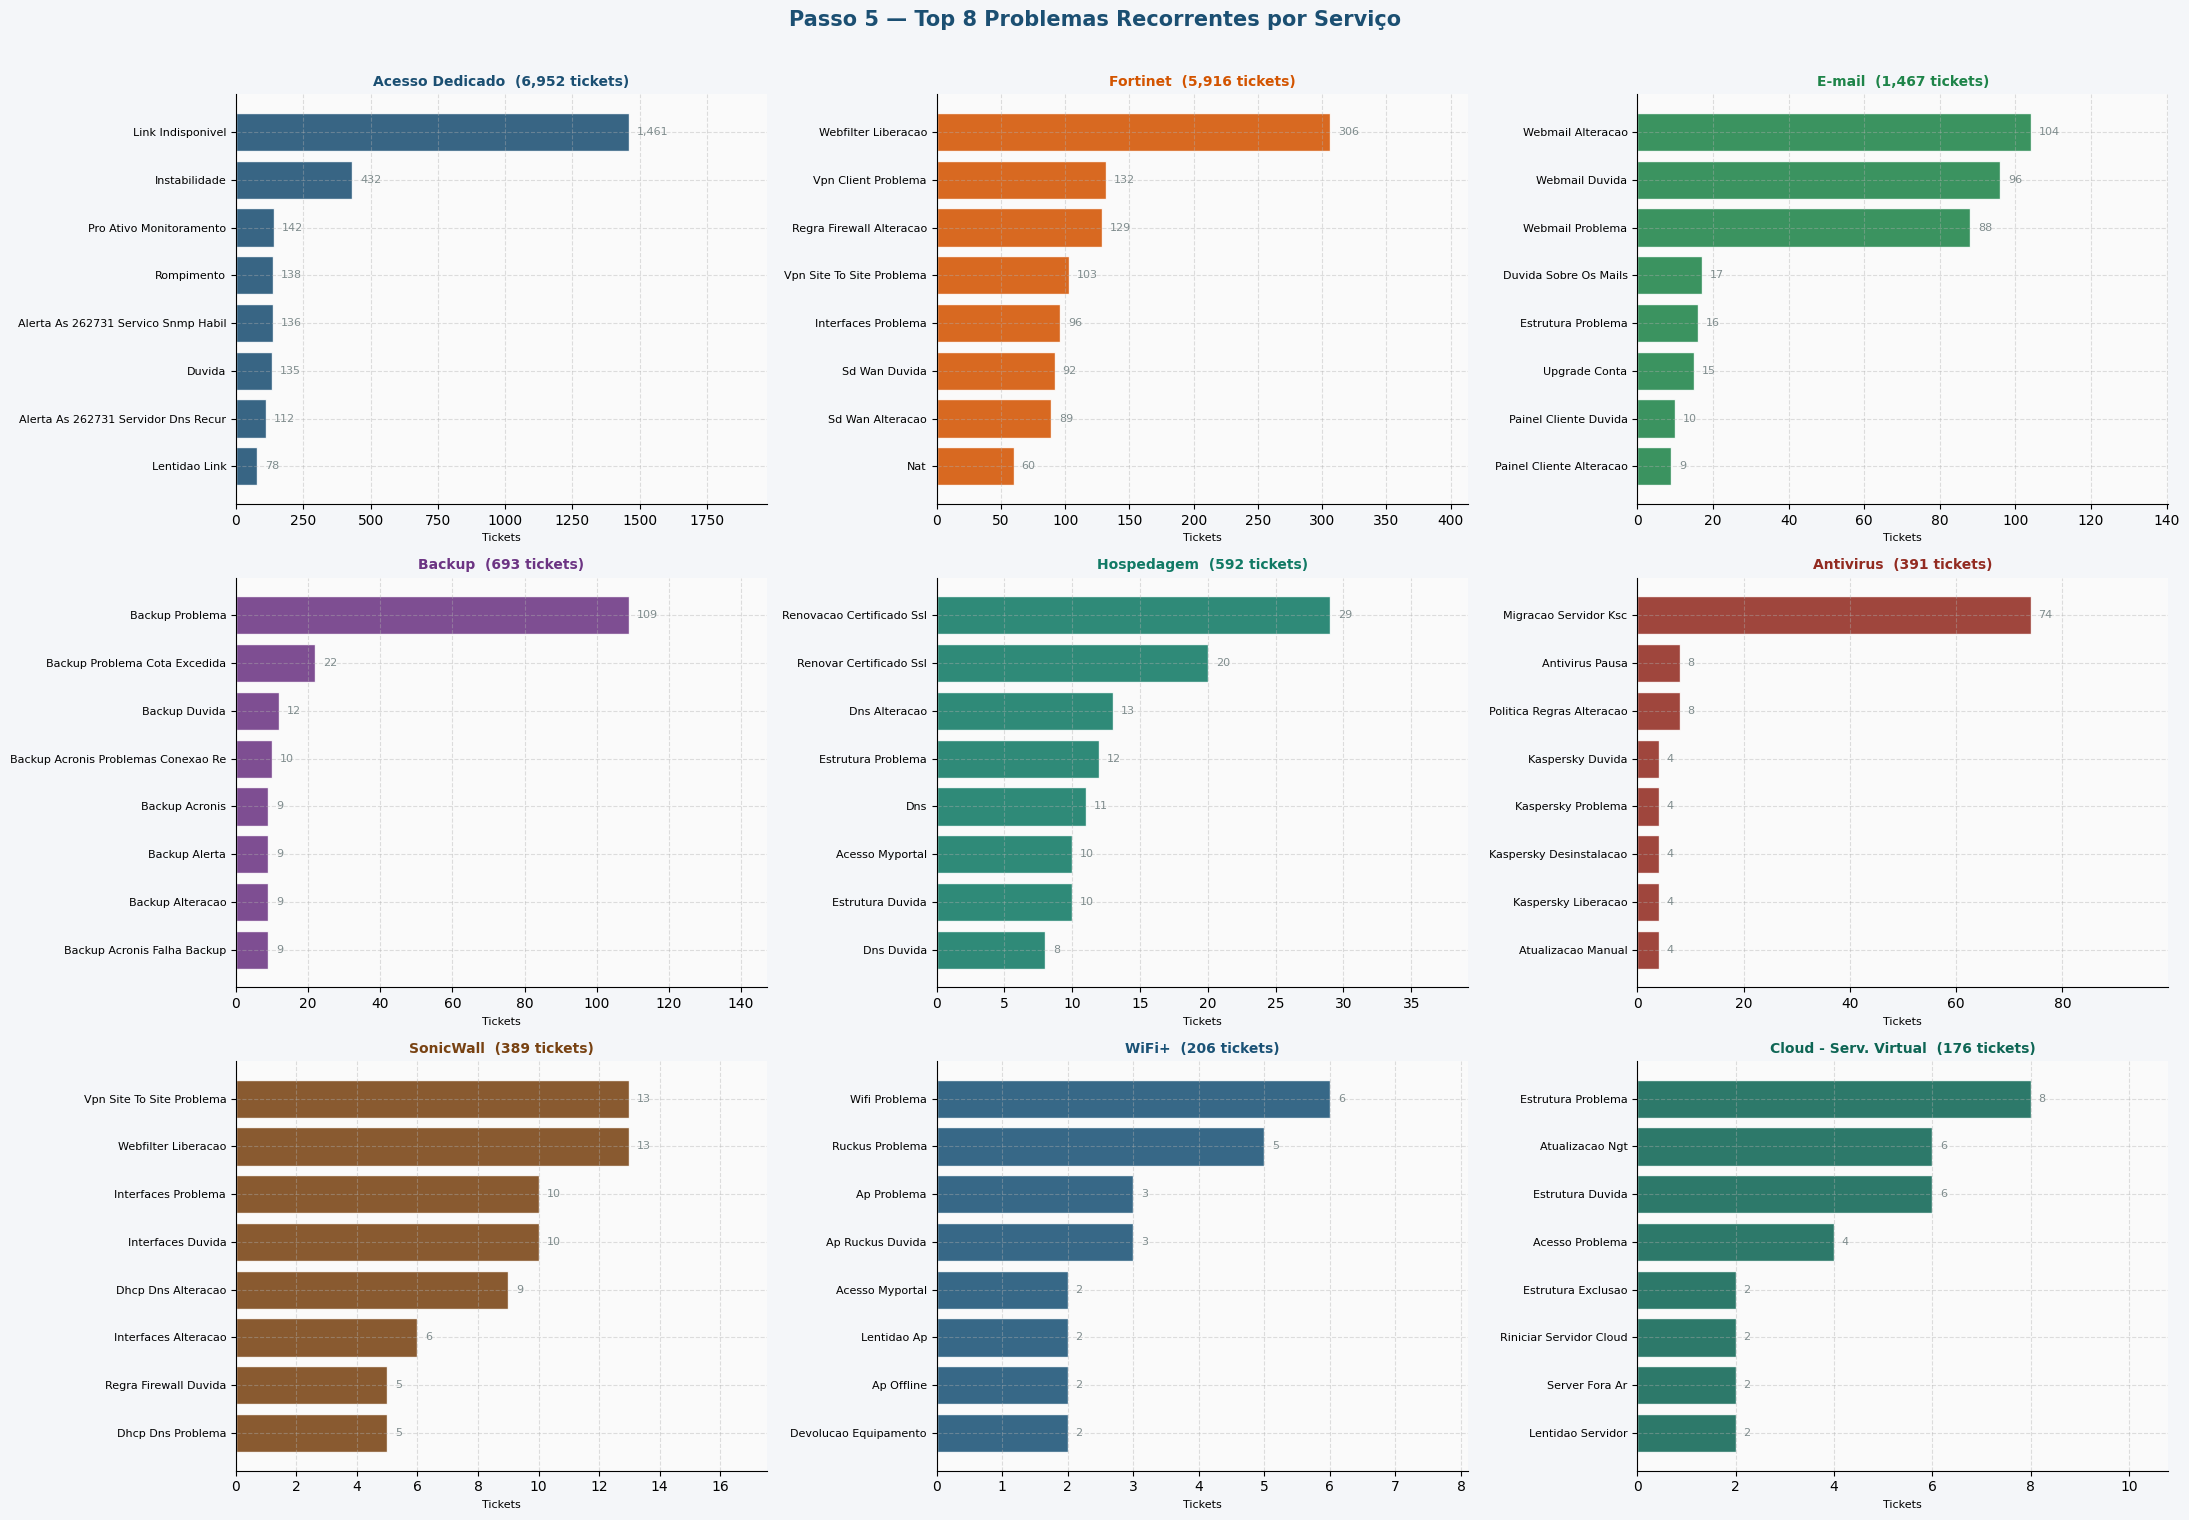

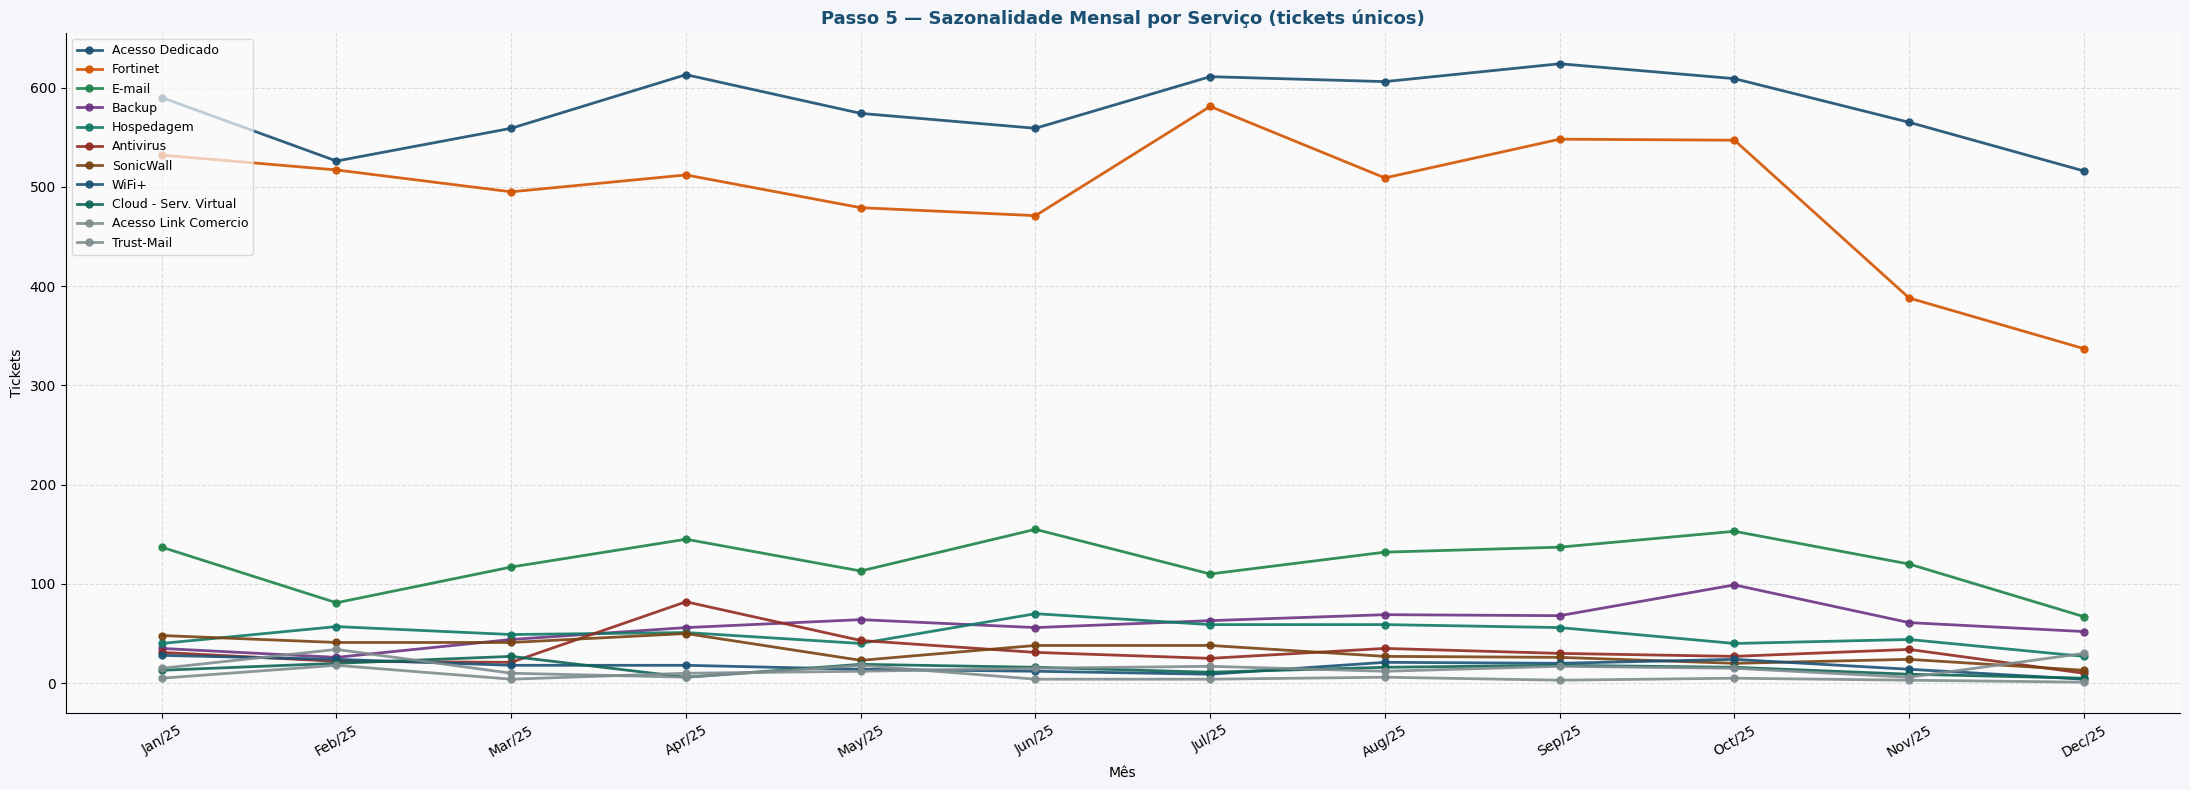

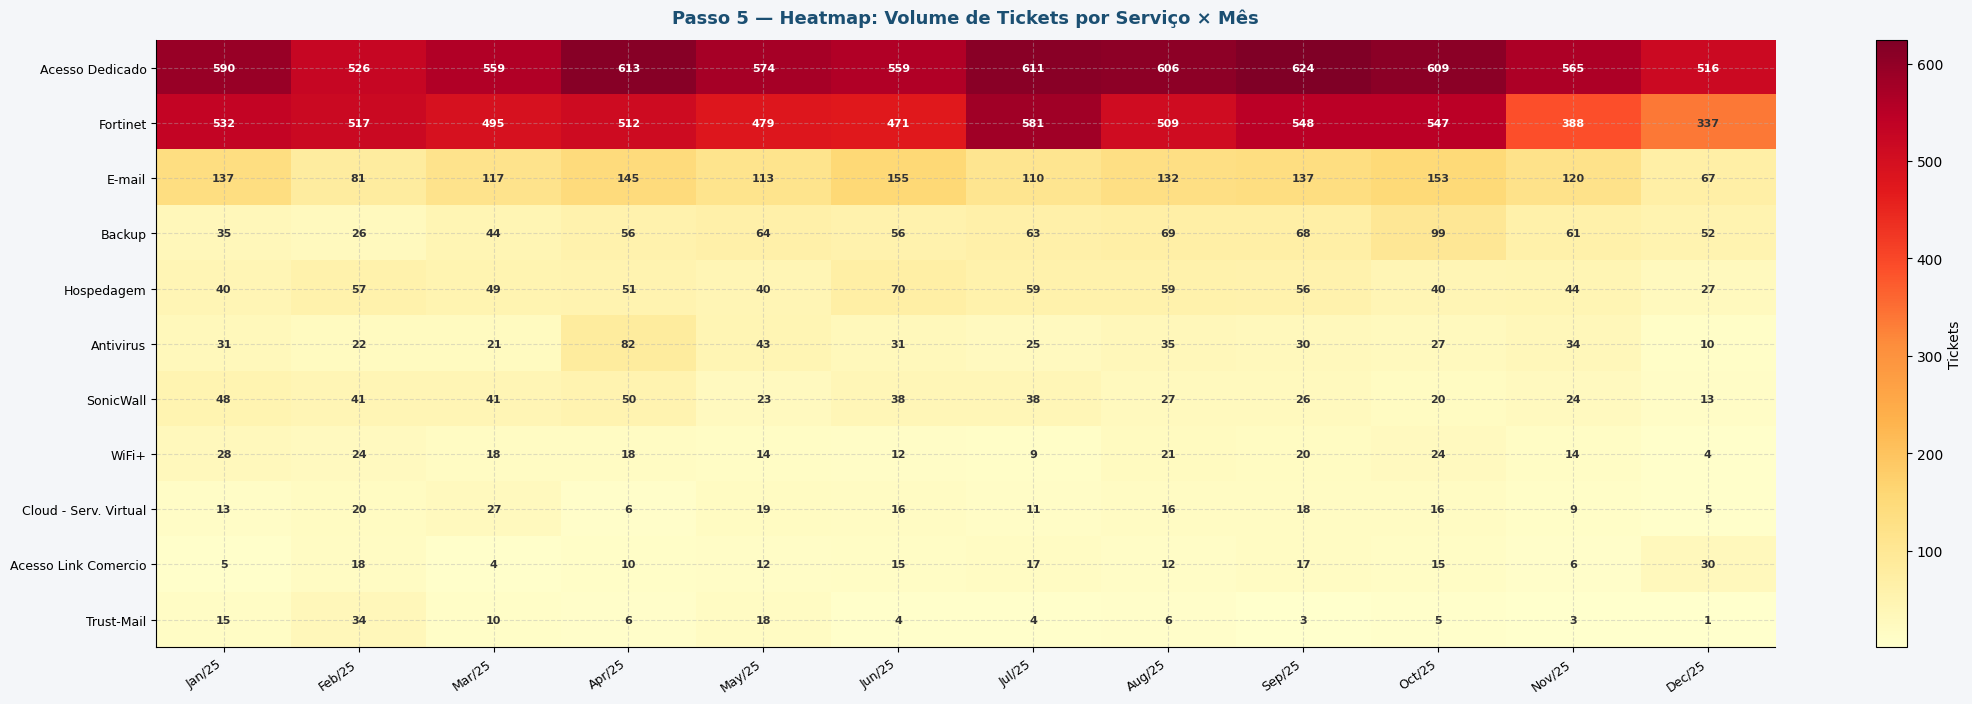

  RESUMO — Problemas Recorrentes por Serviço
  Acesso Dedicado           → "Link Indisponivel"  1,461 tickets (21%)
  Fortinet                  → "Webfilter Liberacao"  306 tickets (5%)
  E-mail                    → "Webmail Alteracao"  104 tickets (7%)
  Backup                    → "Backup Problema"  109 tickets (16%)
  Hospedagem                → "Renovacao Certificado Ssl"  29 tickets (5%)
  Antivirus                 → "Migracao Servidor Ksc"  74 tickets (19%)
  SonicWall                 → "Vpn Site To Site Problema"  13 tickets (3%)
  WiFi+                     → "Wifi Problema"  6 tickets (3%)
  Cloud - Serv. Virtual     → "Estrutura Problema"  8 tickets (5%)
  Acesso Link Comercio      → "Link Indisponivel"  66 tickets (41%)
  Trust-Mail                → "Estrutura Assinatura Bloqueio"  51 tickets (47%)


In [16]:
import unicodedata, re
import matplotlib.gridspec as gridspec

# ── Configuração de cores ────────────────────────────────────────────────────
CORES_SERVICO = {
    'Acesso Dedicado'     : '#1B4F72',
    'Fortinet'            : '#D35400',
    'E-mail'              : '#1E8449',
    'Backup'              : '#6C3483',
    'Hospedagem'          : '#117A65',
    'Antivirus'           : '#922B21',
    'SonicWall'           : '#784212',
    'WiFi+'               : '#1A5276',
    'Cloud - Serv. Virtual': '#0E6655',
}
COR_DEFAULT = '#7F8C8D'

# ── Normalização de títulos ──────────────────────────────────────────────────
def normalizar(t):
    if pd.isna(t): return 'sem titulo'
    t = str(t).strip().lower()
    t = unicodedata.normalize('NFD', t)
    t = ''.join(c for c in t if unicodedata.category(c) != 'Mn')
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\b(criacao|de|do|da|em|com|para|por|no|na|um|uma|e|o|a)\b', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# ── Prepara tickets únicos ───────────────────────────────────────────────────
tickets = df.drop_duplicates(subset='id_ticket').copy()
tickets['data_criacao_dt'] = pd.to_datetime(tickets['data_criacao_ticket'], errors='coerce')
tickets = tickets[tickets['data_criacao_dt'].notna()].copy()
tickets['titulo_norm'] = tickets['titulo'].apply(normalizar)
tickets['mes']          = tickets['data_criacao_dt'].dt.to_period('M')
tickets['mes_str']      = tickets['mes'].dt.strftime('%b/%y')

# Serviços com volume suficiente para análise
servicos_top = tickets['servico'].value_counts()
servicos_top = servicos_top[servicos_top >= 100].index.tolist()

meses_ordem = sorted(tickets['mes'].unique())
meses_label = [m.strftime('%b/%y') for m in meses_ordem]

print(f'Serviços analisados: {len(servicos_top)}')
print(f'Período             : {meses_label[0]} → {meses_label[-1]}')

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Top 8 problemas por serviço (barras horizontais)
# ═══════════════════════════════════════════════════════════════════════════════
n_srv    = min(len(servicos_top), 9)
n_cols   = 3
n_rows   = (n_srv + n_cols - 1) // n_cols

fig1, axes1 = plt.subplots(n_rows, n_cols,
                            figsize=(22, n_rows * 5),
                            facecolor='#F4F6F9')
fig1.suptitle('Passo 5 — Top 8 Problemas Recorrentes por Serviço',
              fontsize=15, fontweight='bold', color=AZUL, y=1.01)

axes1_flat = axes1.flatten() if hasattr(axes1, 'flatten') else [axes1]

for idx, srv in enumerate(servicos_top[:n_srv]):
    ax  = axes1_flat[idx]
    ax.set_facecolor('#FAFAFA')
    cor = CORES_SERVICO.get(srv, COR_DEFAULT)

    sub  = tickets[tickets['servico'] == srv]
    top8 = sub['titulo_norm'].value_counts().head(8)

    # Labels legíveis: title-case, max 35 chars
    labels = [t.replace('-',' ').title()[:35] for t in top8.index]
    vals   = top8.values

    bars = ax.barh(labels[::-1], vals[::-1], color=cor, edgecolor='white', alpha=0.87)
    xmax = vals.max()
    for bar in bars:
        ax.text(bar.get_width() + xmax * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}',
                va='center', fontsize=8, color=CINZA)
    ax.set_xlim(right=xmax * 1.35)
    ax.set_title(f'{srv}  ({sub["id_ticket"].nunique():,} tickets)',
                 fontsize=10, fontweight='bold', color=cor)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlabel('Tickets', fontsize=8)

# Oculta subplots vazios
for idx in range(n_srv, len(axes1_flat)):
    axes1_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Sazonalidade mensal por serviço (linha)
# ═══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(22, 8), facecolor='#F4F6F9')
ax2.set_facecolor('#FAFAFA')

for srv in servicos_top:
    sub      = tickets[tickets['servico'] == srv]
    por_mes  = sub.groupby('mes').size().reindex(meses_ordem, fill_value=0)
    cor      = CORES_SERVICO.get(srv, COR_DEFAULT)
    ax2.plot(meses_label, por_mes.values,
             marker='o', linewidth=2, markersize=5,
             label=srv, color=cor, alpha=0.9)

ax2.set_title('Passo 5 — Sazonalidade Mensal por Serviço (tickets únicos)',
              fontsize=13, fontweight='bold', color=AZUL)
ax2.set_xlabel('Mês', fontsize=10)
ax2.set_ylabel('Tickets', fontsize=10)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9, loc='upper left', framealpha=0.7)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURA 3 — Heatmap: Serviço × Mês
# ═══════════════════════════════════════════════════════════════════════════════
pivot = (
    tickets[tickets['servico'].isin(servicos_top)]
    .groupby(['servico', 'mes'])
    .size()
    .unstack(fill_value=0)
)
pivot.columns = [m.strftime('%b/%y') for m in pivot.columns]
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig3, ax3 = plt.subplots(figsize=(22, max(6, len(pivot) * 0.65)), facecolor='#F4F6F9')
im = ax3.imshow(pivot.values, aspect='auto', cmap='YlOrRd')

ax3.set_xticks(range(len(pivot.columns)))
ax3.set_xticklabels(pivot.columns, rotation=35, ha='right', fontsize=9)
ax3.set_yticks(range(len(pivot.index)))
ax3.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        cor_txt = 'white' if val > pivot.values.max() * 0.6 else '#333333'
        ax3.text(j, i, f'{val:,}', ha='center', va='center',
                 fontsize=8, color=cor_txt, fontweight='bold')

plt.colorbar(im, ax=ax3, label='Tickets')
ax3.set_title('Passo 5 — Heatmap: Volume de Tickets por Serviço × Mês',
              fontsize=13, fontweight='bold', color=AZUL, pad=12)
plt.tight_layout()
plt.show()

# ── Resumo textual ────────────────────────────────────────────────────────────
print('=' * 65)
print('  RESUMO — Problemas Recorrentes por Serviço')
print('=' * 65)
for srv in servicos_top:
    sub  = tickets[tickets['servico'] == srv]
    top1 = sub['titulo_norm'].value_counts().idxmax()
    qt1  = sub['titulo_norm'].value_counts().max()
    pct  = qt1 / len(sub) * 100
    print(f'  {srv:<25} → "{top1.title()[:35]}"  {qt1:,} tickets ({pct:.0f}%)')
print('=' * 65)
